# Demo 01: Quick Start

Build a simple 3-molecule alien biological system from scratch and watch it
converge to equilibrium. This walkthrough shows every step — defining atoms,
molecules, reactions, and assembling them into a runnable simulation.

In [1]:
import sys
from pathlib import Path

# Ensure alienbio is importable
_root = Path(".").resolve().parent.parent / "src"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
_demos = Path(".").resolve().parent
if str(_demos) not in sys.path:
    sys.path.insert(0, str(_demos))

%matplotlib inline


## Step 1 — Define the Chemistry

An AlienBio system starts with **atoms**, **molecules**, and **reactions**.
Here we create a minimal zynol↔brevix↔corthan system where molecules convert
between each other at concentration-dependent rates.

> Every object needs a `dat` (data-access token). In a full scenario these
> come from the catalog; for quick experiments the `MockDat` helper is enough.

In [2]:
from alienbio.bio import (
    AtomImpl, MoleculeImpl, ReactionImpl,
    ChemistryImpl, StateImpl, BioSystem, MockDat,
)

# One atom type — Zyrium
zr = AtomImpl("Zr", name="Zyrium", atomic_weight=14.7)

# Three alien molecules, each containing one Zyrium atom
zynol = MoleculeImpl("zynol", atoms={zr: 1}, bdepth=0, dat=MockDat("mol/zynol"))
brevix = MoleculeImpl("brevix", atoms={zr: 1}, bdepth=0, dat=MockDat("mol/brevix"))
corthan = MoleculeImpl("corthan", atoms={zr: 1}, bdepth=0, dat=MockDat("mol/corthan"))


### Reactions

Each reaction has a **rate function** that depends on the current concentrations.
The forward/reverse pairs create a homeostatic loop that drives the system
toward a stable equilibrium.

```
zynol ──0.10·[zynol]──▸ brevix ──0.08·[brevix]──▸ corthan
zynol ◂──0.05·[brevix]── brevix ◂──0.04·[corthan]── corthan
```

In [3]:
# zynol→brevix and brevix→zynol (forward/reverse)
r_zb = ReactionImpl("r_zb", reactants={zynol: 1.0}, products={brevix: 1.0},
                     rate=lambda s: 0.10 * s["zynol"], dat=MockDat("rxn/r_zb"))
r_bz = ReactionImpl("r_bz", reactants={brevix: 1.0}, products={zynol: 1.0},
                     rate=lambda s: 0.05 * s["brevix"], dat=MockDat("rxn/r_bz"))

# brevix→corthan and corthan→brevix (forward/reverse)
r_bc = ReactionImpl("r_bc", reactants={brevix: 1.0}, products={corthan: 1.0},
                     rate=lambda s: 0.08 * s["brevix"], dat=MockDat("rxn/r_bc"))
r_cb = ReactionImpl("r_cb", reactants={corthan: 1.0}, products={brevix: 1.0},
                     rate=lambda s: 0.04 * s["corthan"], dat=MockDat("rxn/r_cb"))


## Step 2 — Assemble and Run

A `ChemistryImpl` bundles atoms, molecules, and reactions. A `StateImpl` sets
the initial concentrations. A `BioSystem` ties it together and can be stepped
forward in time.

In [4]:
chem = ChemistryImpl(
    "zbc",
    atoms={"Zr": zr},
    molecules={"zynol": zynol, "brevix": brevix, "corthan": corthan},
    reactions={"r_zb": r_zb, "r_bz": r_bz, "r_bc": r_bc, "r_cb": r_cb},
    dat=MockDat("chem/zbc"),
)

# Start with all concentration in zynol
state = StateImpl(chem, initial={"zynol": 10.0, "brevix": 0.0, "corthan": 0.0})
system = BioSystem(chem, state, dt=0.1)

# Run 500 time steps — returns a timeline (list of concentration snapshots)
timeline = system.run(500)

print(f"Steps: {len(timeline)}")
print(f"Final: { {m: round(system.state[m], 3) for m in system.state} }")


Steps: 501
Final: {'zynol': 1.593, 'brevix': 2.955, 'corthan': 5.452}


## Step 3 — Visualize

`alienbio.viz` provides ready-made plots. `concentration_trajectory` shows how
each molecule's concentration changes over time. `equilibrium_convergence` shows
the rolling variance — when it drops below a threshold the system has stabilized.

### Concentration Trajectories

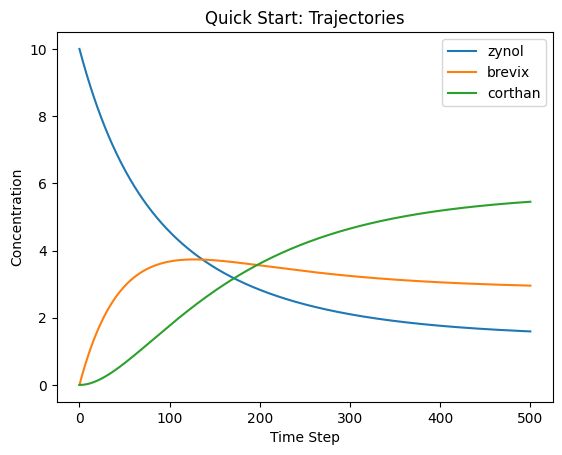

In [5]:
from alienbio.viz import concentration_trajectory, equilibrium_convergence

concentration_trajectory(timeline, title="Quick Start: Trajectories");


### Equilibrium Convergence

The variance of each molecule's concentration over a trailing window.
Once all variances drop below a threshold, the system is at equilibrium.

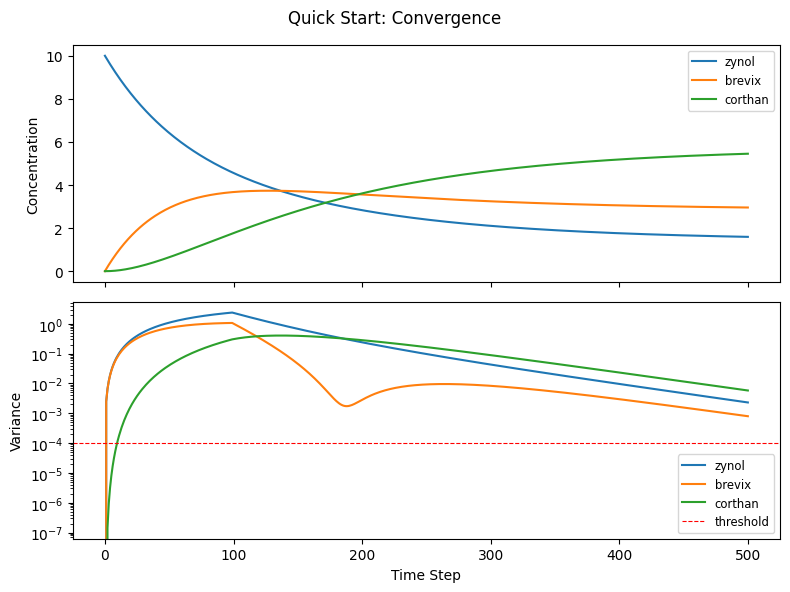

In [6]:
equilibrium_convergence(timeline, title="Quick Start: Convergence");